# BMAD EDA

Exploratory look at the [BMAD benchmark](https://github.com/DorisBao/BMAD) before
applying the reproduced Dinomaly2 pipeline to it (see `../src/data/bmad.py` and
`bmad_dinomaly2_train.ipynb` in this folder).

BMAD packages six medical imaging datasets into a common normal-vs-abnormal
anomaly-detection format, one dataset per modality:

| modality | source dataset | organ / imaging | pixel masks |
|---|---|---|---|
| `brain` | BraTS2021 (sliced to 2D) | brain MRI | yes |
| `liver` | hist_DIY (BTCV/LiTS-derived) | liver CT | yes |
| `retina_resc` | RESC | retinal OCT | yes |
| `chest` | Chest-RSNA | chest X-ray | no |
| `histopathology` | Camelyon16 (256x256 patches) | lymph node histopathology | no |
| `retina_oct` | OCT2017 | retinal OCT | no |

Unlike MVTec-AD/VisA (Dinomaly2's own benchmarks), there is no category
dimension inside a modality: each one is already a single-class
normal-vs-abnormal problem. The on-disk layout is also inconsistent across
modalities, since each comes from a different upstream preparation script.
`src/data/bmad.py` hardcodes those per-modality quirks (folder capitalization,
presence of pixel masks); this notebook checks that against what is actually
on disk and looks at what the images and masks look like before training on
them.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../..')  # notebooks/bmad/ -> repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src.data.bmad import MODALITIES, resolve_bmad_root

BMAD_ROOT = resolve_bmad_root()
MODALITY_NAMES = list(MODALITIES)

# Fixed categorical order/palette for the 6 modalities, used consistently in
# every chart below (seaborn's colorblind-safe qualitative palette).
PALETTE = dict(zip(MODALITY_NAMES, plt.get_cmap('tab10').colors))
print(f'BMAD root: {BMAD_ROOT}')
print(f'modalities: {MODALITY_NAMES}')

BMAD root: /Users/toriav/Desktop/Erem/BC Cancer/Anomaly Detection/mammo-uad-2d3d/data/BMAD
modalities: ['brain', 'liver', 'retina_resc', 'chest', 'histopathology', 'retina_oct']


## 1. Split sizes

Counts straight off disk, independent of `src/data/bmad.py`'s Dataset classes, as a sanity check that the loader's per-modality config (abnormal-folder name, has_masks) actually matches what's there.

In [2]:
def count_split(root, split_dir, sub):
    p = root / split_dir / sub / 'img'
    return len(list(p.glob('*.png'))) if p.exists() else 0

rows = []
for name, cfg in MODALITIES.items():
    root = BMAD_ROOT / cfg.subpath
    n_train = len(list((root / 'train' / 'good').glob('*.png')))
    n_val_good = count_split(root, cfg.val_dir, 'good')
    n_val_abn = count_split(root, cfg.val_dir, cfg.abnormal_dir)
    n_test_good = count_split(root, 'test', 'good')
    n_test_abn = count_split(root, 'test', cfg.abnormal_dir)
    n_masks = len(list((root / 'test' / cfg.abnormal_dir / 'label').glob('*.png'))) if cfg.has_masks else 0
    rows.append(dict(
        modality=name, subpath=cfg.subpath, train_good=n_train,
        val_good=n_val_good, val_abnormal=n_val_abn,
        test_good=n_test_good, test_abnormal=n_test_abn,
        has_masks=cfg.has_masks, n_masks_found=n_masks,
        masks_match_abnormal=(n_masks == n_test_abn) if cfg.has_masks else None,
    ))

summary = pd.DataFrame(rows).set_index('modality')
summary

,subpath,train_good,val_good,val_abnormal,test_good,test_abnormal,has_masks,n_masks_found,masks_match_abnormal
modality,,,,,,,,,
brain,Brain_AD/BraTS2021_slice,7500,39,44,640,3075,True,3075,True
liver,Liver_AD/hist_DIY,1542,93,73,833,660,True,660,True
retina_resc,Retina_RESC_AD/RESC,4297,45,70,1041,764,True,764,True
chest,Chest_AD/Chest-RSNA,8000,70,1420,781,16413,False,0,None
histopathology,Histopathology_AD/camelyon16_256,5088,117,119,1003,994,False,0,None
retina_oct,Retina_OCT2017_AD/OCT2017,26315,8,24,242,726,False,0,None


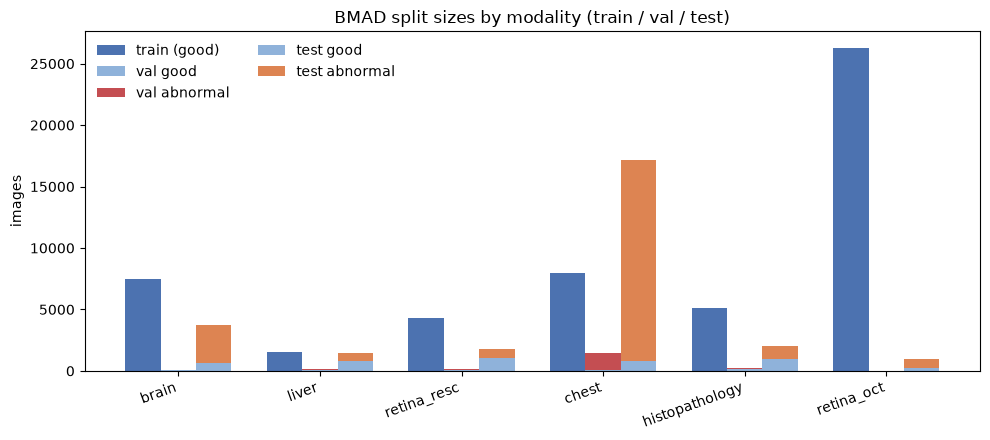

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(summary))
width = 0.25
ax.bar(x - width, summary['train_good'], width, label='train (good)', color='#4c72b0')
ax.bar(x, summary['val_good'], width, label='val good', color='#8fb2da')
ax.bar(x, summary['val_abnormal'], width, bottom=summary['val_good'], label='val abnormal', color='#c44e52')
ax.bar(x + width, summary['test_good'], width, label='test good', color='#8fb2da')
ax.bar(x + width, summary['test_abnormal'], width, bottom=summary['test_good'],
       label='test abnormal', color='#dd8452')
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=20, ha='right')
ax.set_ylabel('images')
ax.set_title('BMAD split sizes by modality (train / val / test)')
ax.legend(frameon=False, ncol=2)
fig.tight_layout()

## 2. Image properties

Mode (grayscale/RGB/RGBA) and resolution vary by modality. The loader converts everything to RGB (`Image.open(...).convert('RGB')`, same as Dinomaly2's own `MVTecDataset`) before the resize/crop/normalize transform, so this is to establish what is being converted from, and whether a modality has a single fixed resolution.

In [4]:
import random

def sample_image_props(img_dir, n=25, seed=0):
    paths = list(img_dir.glob('*.png'))
    if not paths:
        return pd.DataFrame()
    random.Random(seed).shuffle(paths)
    rows = []
    for p in paths[:n]:
        with Image.open(p) as im:
            rows.append(dict(mode=im.mode, width=im.width, height=im.height))
    return pd.DataFrame(rows)

prop_rows = []
for name, cfg in MODALITIES.items():
    root = BMAD_ROOT / cfg.subpath
    df = sample_image_props(root / 'train' / 'good')
    if df.empty:
        continue
    prop_rows.append(dict(
        modality=name,
        modes=', '.join(sorted(df['mode'].unique())),
        width_range=f"{df['width'].min()}-{df['width'].max()}",
        height_range=f"{df['height'].min()}-{df['height'].max()}",
        fixed_size=(df['width'].nunique() == 1 and df['height'].nunique() == 1),
    ))

pd.DataFrame(prop_rows).set_index('modality')

,modes,width_range,height_range,fixed_size
modality,,,,
brain,RGBA,240-240,240-240,True
liver,L,512-512,512-512,True
retina_resc,L,512-512,1024-1024,True
chest,L,1024-1024,1024-1024,True
histopathology,RGB,256-256,256-256,True
retina_oct,RGB,512-1536,496-512,False


## 3. Sample images

Two normal + two abnormal test images per modality; mask overlay in red for the three modalities that ship pixel-level ground truth.

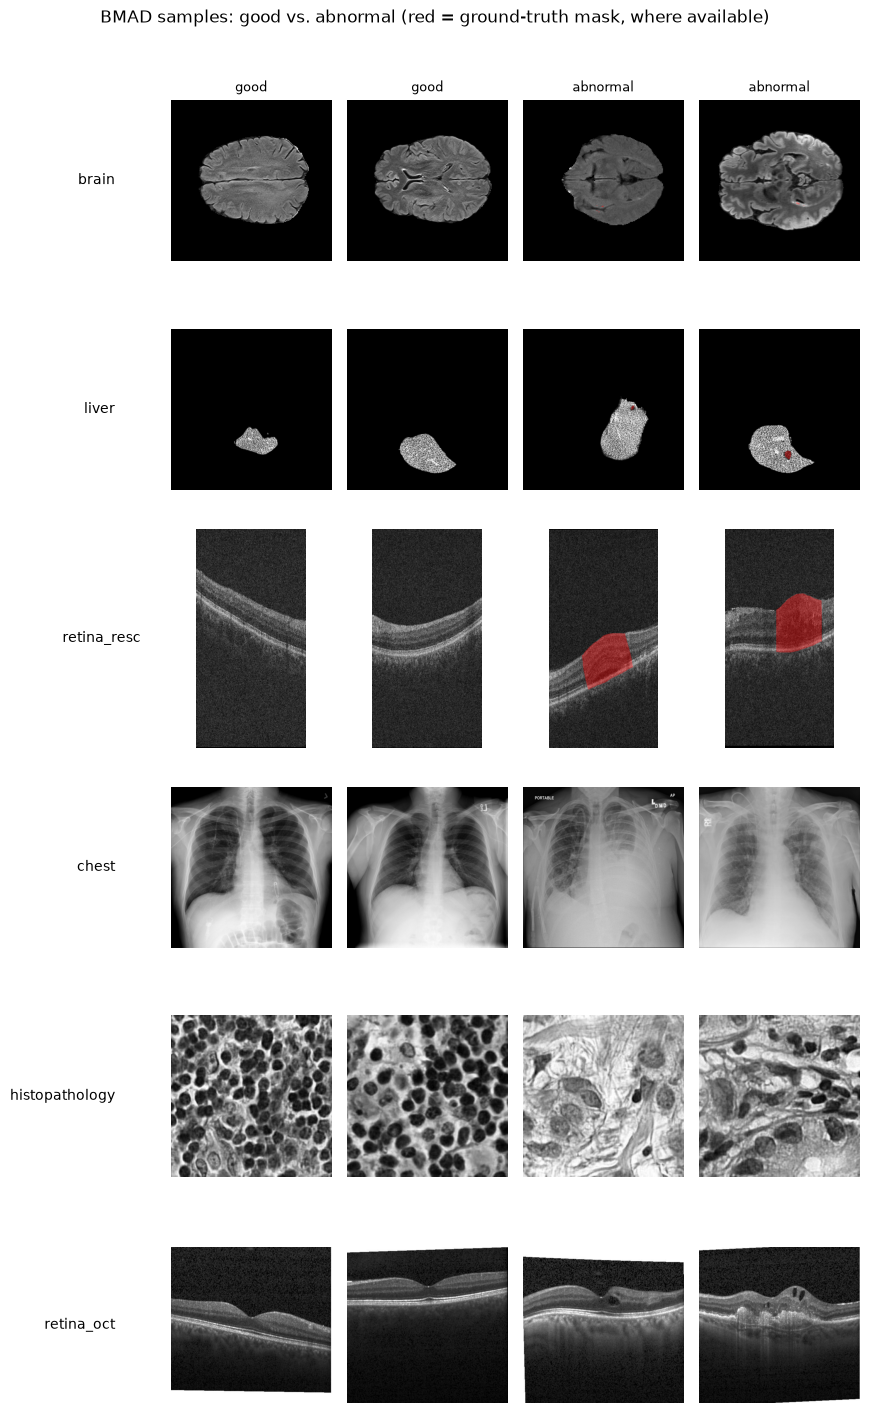

In [5]:
def load_pair(root, cfg, n_each=2, seed=0):
    good_paths = sorted((root / 'test' / 'good' / 'img').glob('*.png'))
    abn_paths = sorted((root / 'test' / cfg.abnormal_dir / 'img').glob('*.png'))
    rng = random.Random(seed)
    good = rng.sample(good_paths, min(n_each, len(good_paths)))
    abn = rng.sample(abn_paths, min(n_each, len(abn_paths)))
    return good, abn

n_each = 2
fig, axes = plt.subplots(len(MODALITIES), 2 * n_each, figsize=(2.2 * 2 * n_each, 2.4 * len(MODALITIES)))

for row, (name, cfg) in enumerate(MODALITIES.items()):
    root = BMAD_ROOT / cfg.subpath
    good, abn = load_pair(root, cfg, n_each=n_each)
    for col, p in enumerate(good):
        ax = axes[row, col]
        ax.imshow(Image.open(p).convert('L'), cmap='gray')
        ax.set_title('good' if row == 0 else '', fontsize=9)
        ax.axis('off')
    for col, p in enumerate(abn):
        ax = axes[row, n_each + col]
        img = np.array(Image.open(p).convert('L'))
        ax.imshow(img, cmap='gray')
        if cfg.has_masks:
            mask_path = root / 'test' / cfg.abnormal_dir / 'label' / p.name
            if mask_path.exists():
                mask = np.array(Image.open(mask_path).convert('L')) > 0
                overlay = np.zeros((*mask.shape, 4))
                overlay[mask] = [1, 0, 0, 0.4]
                ax.imshow(overlay)
        ax.set_title('abnormal' if row == 0 else '', fontsize=9)
        ax.axis('off')
    axes[row, 0].set_ylabel(name, rotation=0, ha='right', va='center', fontsize=10, labelpad=40)
    axes[row, 0].axis('on')
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    for spine in axes[row, 0].spines.values():
        spine.set_visible(False)

fig.suptitle('BMAD samples: good vs. abnormal (red = ground-truth mask, where available)', y=1.0)
fig.tight_layout()

## 4. Notes for training

- **Everything converts to RGB.** Chest/Liver/RESC ship grayscale (`L`), Brain ships `RGBA`, Histopathology/OCT2017 are already `RGB`. `src/data/bmad.py` converts all of them the same way Dinomaly2's own MVTec loader does, so the frozen DINOv2 encoder (trained on RGB ImageNet) sees a consistent 3-channel input regardless of source modality.
- **Only Brain, Liver, and RESC have pixel-level masks.** Chest, Histopathology, and OCT2017 are image-level-only benchmarks. `src/eval/bmad.py` reports P-AUROC/P-AP/P-F1/P-AUPRO only for the first group and falls back to an image-only scorer for the second, rather than computing pixel metrics against an all-zero placeholder mask, which would be meaningless.
- **Every modality ships its own val split** (named `valid/` for Brain/Liver/Histopathology, `val/` for Chest/RESC/OCT2017, another BMAD folder-naming inconsistency; see `ModalityConfig.val_dir`), much smaller than test (see the split-size table above). `src/training/train_bmad.py` evaluates both at every checkpoint: val picks which checkpoint to keep (`best_checkpoint.pt`, by val I-AUROC), test is what gets reported, so a run never grades its own checkpoint selection against the numbers it is judged on.
- **Resolutions vary within a modality** (most visibly OCT2017), so the fixed `resize -> center-crop` transform (448 -> 392, matching the Dinomaly2 MVTec/VisA config) will letterbox or crop some images more aggressively than others; worth revisiting per modality if a specific one underperforms.
- Each modality trains its own model (single-class setting); see `bmad_dinomaly2_train.ipynb`.